# 06 · Analgesic medication use pre vs post DBS

Parse PPMI `Concomitant_Medication_Log` for analgesics (opioids, NSAIDs, neuropathic-pain agents, acetaminophen, muscle relaxants). Compute per-patient pre and post analgesic counts using the same windows as notebook 01 ([-12,0] vs [+6,+18] months, patient-specific anchor). Does DBS coincide with lower analgesic use — even if NP1PAIN mean is unchanged?

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(lubridate); library(stringr) })

path_conmed <- file.path(PROJECT_ROOT, "Propensity score DBS sleep",
                        "Data I need to merge",
                        "Concomitant_Medication_Log_04Nov2024.csv")
cm <- readr::read_csv(path_conmed, show_col_types = FALSE) %>%
  dplyr::mutate(
    PATNO = as.integer(PATNO),
    CMTRT = toupper(CMTRT),
    STARTDT = suppressWarnings(lubridate::my(STARTDT)),
    STOPDT  = suppressWarnings(lubridate::my(STOPDT))
  )
cat("Concomitant med rows:", nrow(cm), "  unique patients:", dplyr::n_distinct(cm$PATNO), "\n")
cm %>% dplyr::count(CMTRT, sort = TRUE) %>% head(20)

Concomitant med rows: 42556   unique patients: 4092 


CMTRT,n
<chr>,<int>
ASPIRIN,942
ATORVASTATIN,810
VITAMIN D,734
MULTIVITAMIN,697
MELATONIN,566
LEVOTHYROXINE,504
VITAMIN D3,491
CLONAZEPAM,476
LISINOPRIL,450


In [2]:
pat_regex <- toupper(ANALGESIC_REGEX)
cm_an <- cm %>% dplyr::filter(!is.na(CMTRT), stringr::str_detect(CMTRT, pat_regex))
cat("Analgesic rows matched:", nrow(cm_an), "  patients:", dplyr::n_distinct(cm_an$PATNO), "\n")

# Top matched drug names (quick QC)
cm_an %>% dplyr::count(CMTRT, sort = TRUE) %>% head(30)

Analgesic rows matched: 3900   patients: 1839 


CMTRT,n
<chr>,<int>
ASPIRIN,942
IBUPROFEN,362
GABAPENTIN,356
MELOXICAM,151
TYLENOL,139
BABY ASPIRIN,118
ACETAMINOPHEN,113
NAPROXEN,107
DULOXETINE,100


In [3]:
# Anchor dates (patient-specific) from the full cohort
rel <- load_full_ppmi_rel_patient_anchor()
anchors <- rel %>% dplyr::distinct(PATNO, will_receive_dbs, anchor_date)
cat("Anchor rows:", nrow(anchors), "\n")

# Compute per-patient analgesic presence flag in each window
window_flag <- function(cm_in, anchors_in, win_lo, win_hi) {
  cm_in %>% dplyr::inner_join(anchors_in, by = "PATNO") %>%
    dplyr::mutate(
      start_rel = as.numeric(difftime(STARTDT, anchor_date, units = "days")) / DAYS_PER_MONTH,
      stop_rel  = as.numeric(difftime(dplyr::coalesce(STOPDT, as.Date("2099-12-31")),
                                      anchor_date, units = "days")) / DAYS_PER_MONTH
    ) %>%
    dplyr::filter(!is.na(start_rel)) %>%
    dplyr::filter(start_rel <= win_hi, stop_rel >= win_lo) %>%
    dplyr::distinct(PATNO)
}
pre_set  <- window_flag(cm_an, anchors, -12, 0)
post_set <- window_flag(cm_an, anchors,  6, 18)

per_pat <- anchors %>%
  dplyr::mutate(
    any_pre_analgesic  = PATNO %in% pre_set$PATNO,
    any_post_analgesic = PATNO %in% post_set$PATNO,
    status = dplyr::case_when(
      !any_pre_analgesic & any_post_analgesic ~ "Started",
       any_pre_analgesic & !any_post_analgesic ~ "Stopped",
       any_pre_analgesic &  any_post_analgesic ~ "Continued",
      TRUE                                      ~ "Never")
  )
print(per_pat %>% dplyr::count(will_receive_dbs, status, name = "n") %>% tidyr::pivot_wider(names_from = status, values_from = n, values_fill = 0))
save_object(per_pat, "analgesic_status")

Anchor rows: 1484 


# A tibble: 2 × 4
  will_receive_dbs Continued Never Started
  <lgl>                <int> <int>   <int>
1 FALSE                  147  1208      24
2 TRUE                    27    73       5


In [4]:
# Chi-square and risk-ratio: stopping analgesic given DBS among those on analgesic pre
on_pre <- per_pat %>% dplyr::filter(any_pre_analgesic)
cat("Patients on an analgesic in the pre window:", nrow(on_pre), "\n")
print(on_pre %>% dplyr::count(will_receive_dbs, status))
if (nrow(on_pre) > 0) {
  tab <- table(on_pre$will_receive_dbs, on_pre$status)
  print(tab)
  print(suppressWarnings(stats::chisq.test(tab)))
  # Proportion who stopped, by arm
  p_stop <- on_pre %>% dplyr::group_by(will_receive_dbs) %>%
    dplyr::summarise(n = dplyr::n(), stopped = sum(status == "Stopped"),
                     prop_stopped = stopped / n, .groups = "drop")
  print(p_stop)
  save_table(p_stop, "analgesic_stop_rate_by_arm")
}

Patients on an analgesic in the pre window: 174 


# A tibble: 2 × 3
  will_receive_dbs status        n
  <lgl>            <chr>     <int>
1 FALSE            Continued   147
2 TRUE             Continued    27


       
        Continued
  FALSE       147
  TRUE         27

	Chi-squared test for given probabilities

data:  tab
X-squared = 82.759, df = 1, p-value < 2.2e-16

# A tibble: 2 × 4
  will_receive_dbs     n stopped prop_stopped
  <lgl>            <int>   <int>        <dbl>
1 FALSE              147       0            0
2 TRUE                27       0            0


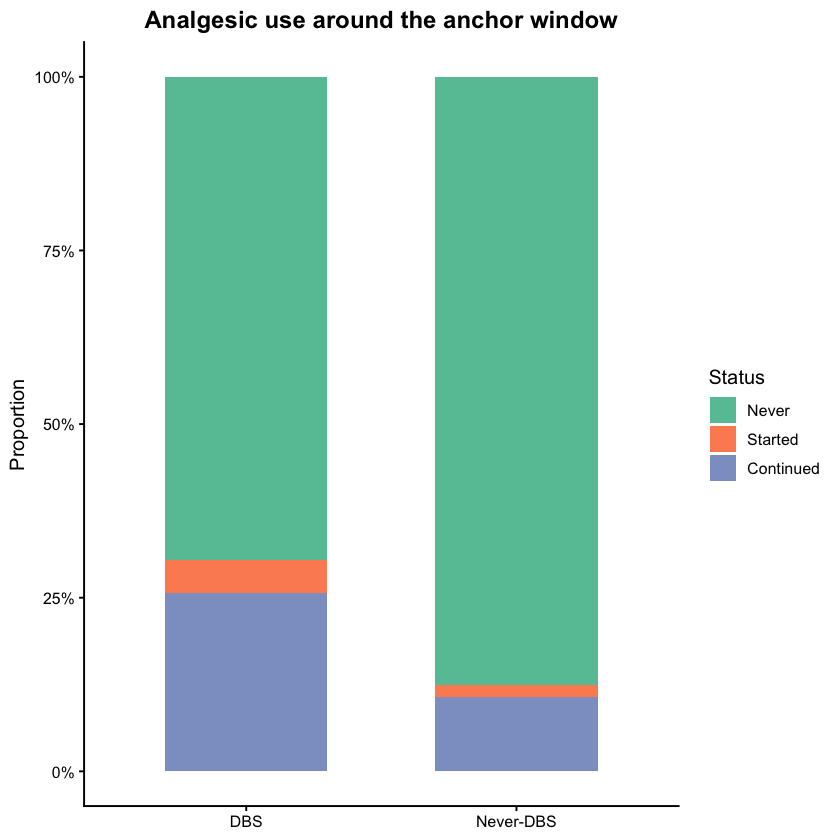

In [5]:
arm_labs <- c(`TRUE` = "DBS", `FALSE` = "Never-DBS")
p_stat <- per_pat %>% dplyr::count(will_receive_dbs, status) %>%
  dplyr::group_by(will_receive_dbs) %>% dplyr::mutate(prop = n / sum(n)) %>% dplyr::ungroup() %>%
  dplyr::mutate(arm = dplyr::recode(as.character(will_receive_dbs), !!!arm_labs),
                status = factor(status, levels = c("Never","Started","Continued","Stopped")))
p_bar <- ggplot(p_stat, aes(x = arm, y = prop, fill = status)) +
  geom_col(position = "fill", width = 0.6) +
  scale_y_continuous("Proportion", labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Analgesic use around the anchor window",
       x = NULL, fill = "Status") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))
p_bar
save_fig(p_bar, "Fig14_analgesic_status", width = 6, height = 4.2)